# AI Studio SPbGU Reproduction

Максимально близкое воспроизведение `D:/Downloads/ai_studio_code.py` на локальном `spbgu_data`.

Ключевые отличия от модульного пайплайна:
- `np.flipud(grid)`;
- вычитание медианы по строкам;
- target `mask > 0`, то есть тела зерен;
- `RandomCrop(256, 256)` через Albumentations;
- `0.5 * BCE + 0.5 * Dice`;
- `Adam(lr=3e-4)`.


In [1]:
from pathlib import Path
import os
import csv
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm.auto import tqdm


PROJECT_ROOT = Path(r'D:/Nornikel-2026-Shlif-Case')
DATA_ROOT = PROJECT_ROOT / 'spbgu_data' / 'сталь 09Г2С'
OUT = PROJECT_ROOT / 'notebooks' / 'spbgu_unet_experiments' / 'outputs' / 'ai_studio_reproduction'
RUN_DIR = OUT / 'run'
PREVIEW_DIR = OUT / 'previews'
RUN_DIR.mkdir(parents=True, exist_ok=True)
PREVIEW_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('DATA_ROOT exists:', DATA_ROOT.exists())


device: cuda
DATA_ROOT exists: True


In [2]:
all_files = []
for root, _, files in os.walk(DATA_ROOT):
    for filename in files:
        all_files.append(str(Path(root) / filename))

local_images = sorted([
    path for path in all_files
    if path.lower().endswith('.jpg') and '_100' not in path and '_500' not in path
])

local_pairs = []
for image_path in local_images:
    mask_path = str(Path(image_path).with_suffix('.bmp'))
    txt_path = str(Path(image_path).with_suffix('.txt'))
    if mask_path in all_files and txt_path in all_files:
        local_pairs.append((txt_path, mask_path))

local_txt_paths = [pair[0] for pair in local_pairs]
local_mask_paths = [pair[1] for pair in local_pairs]

val_idx = [3, 7, 11, 15]
train_txt_paths = [path for idx, path in enumerate(local_txt_paths) if idx not in val_idx]
train_mask_paths = [path for idx, path in enumerate(local_mask_paths) if idx not in val_idx]
val_txt_paths = [local_txt_paths[idx] for idx in val_idx]
val_mask_paths = [local_mask_paths[idx] for idx in val_idx]

print('pairs:', len(local_pairs))
print('train:', len(train_txt_paths), 'val:', len(val_txt_paths))
pd.DataFrame({'txt': local_txt_paths, 'mask': local_mask_paths})


pairs: 16
train: 12 val: 4


,txt,mask
0,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...
1,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...
2,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...
3,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...
4,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...
5,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...
6,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...
7,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...
8,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...
9,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...


In [3]:
def load_ntmdt_ascii_pro(txt_path):
    with open(txt_path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    nx, ny = 512, 512
    start_idx = 0
    for idx, line in enumerate(lines):
        if 'NX =' in line:
            nx = int(line.split('=')[1].strip())
        if 'NY =' in line:
            ny = int(line.split('=')[1].strip())
        if 'Start of Data' in line:
            start_idx = idx + 1
            break
    data_values = np.fromstring(' '.join(lines[start_idx:]), dtype=np.float32, sep=' ')
    grid = data_values[: nx * ny].reshape((ny, nx))
    grid = np.flipud(grid)
    grid = grid - np.median(grid, axis=1, keepdims=True)
    return grid


def height_to_rgb(txt_path):
    raw_heights = load_ntmdt_ascii_pro(txt_path)
    h_min, h_max = np.percentile(raw_heights, 2), np.percentile(raw_heights, 98)
    clipped = np.clip(raw_heights, h_min, h_max)
    if h_max > h_min:
        normalized = (clipped - h_min) / (h_max - h_min) * 255.0
    else:
        normalized = clipped * 0.0
    return cv2.cvtColor(normalized.astype(np.uint8), cv2.COLOR_GRAY2RGB)


class SteelDatasetPro(Dataset):
    def __init__(self, txt_paths, mask_paths, transform=None):
        self.txt_paths = txt_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.txt_paths)

    def __getitem__(self, idx):
        image = height_to_rgb(self.txt_paths[idx])
        # Читаем файл через numpy (обход бага OpenCV с кириллицей на Windows)
        mask_array = np.fromfile(self.mask_paths[idx], dtype=np.uint8)
        mask = cv2.imdecode(mask_array, cv2.IMREAD_GRAYSCALE)

        if mask is None:
            raise ValueError(f"Не удалось прочитать маску по пути: {self.mask_paths[idx]}")
        mask_binary = (mask > 0).astype(np.float32)
        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask_binary)
            image = augmented['image']
            mask_binary = augmented['mask']
        mask_binary = mask_binary.unsqueeze(0)
        return image, mask_binary, self.txt_paths[idx]


In [4]:
train_transform = A.Compose([
    A.RandomCrop(width=256, height=256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.3, contrast=0.4, saturation=0.3, hue=0.1, p=0.6),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        A.MotionBlur(blur_limit=(3, 5), p=1.0),
    ], p=0.4),
    A.CoarseDropout(max_holes=8, max_height=16, max_width=16, p=0.4),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

train_loader = DataLoader(SteelDatasetPro(train_txt_paths, train_mask_paths, transform=train_transform), batch_size=4, shuffle=True)
val_loader = DataLoader(SteelDatasetPro(val_txt_paths, val_mask_paths, transform=val_transform), batch_size=1, shuffle=False)


C:\Users\Computer\AppData\Local\Temp\ipykernel_7784\1349430548.py:11: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=16, max_width=16, p=0.4),


OpenCV не загрузил, пробуем PIL: D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 09Г2С\1_Поставка\9A003\9A003_1.bmp


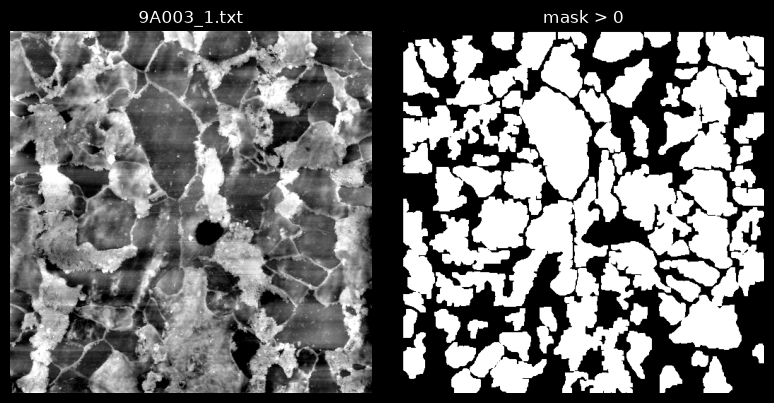

In [5]:
import cv2
import numpy as np
from PIL import Image
import os

def load_image_safe(image_path, grayscale=True):
    """
    Универсальная загрузка изображения с пробой через разные библиотеки
    """
    # Проверяем существование файла
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Файл не найден: {image_path}")

    # Пробуем через OpenCV
    if grayscale:
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    else:
        img = cv2.imread(image_path)

    # Если OpenCV не справился, пробуем через PIL
    if img is None:
        try:
            print(f"OpenCV не загрузил, пробуем PIL: {image_path}")
            pil_img = Image.open(image_path)
            if grayscale:
                img = np.array(pil_img.convert('L'))
            else:
                img = np.array(pil_img)
        except Exception as e:
            raise ValueError(f"Не удалось загрузить изображение {image_path}: {e}")

    return img

# Использование
sample_image = height_to_rgb(train_txt_paths[0])

try:
    mask_path = train_mask_paths[0]
    sample_mask_raw = load_image_safe(mask_path, grayscale=True)
    sample_mask = sample_mask_raw > 0
except Exception as e:
    print(f"Ошибка: {e}")
    sample_mask = np.zeros((512, 512), dtype=bool)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_image)
axes[0].set_title(Path(train_txt_paths[0]).name)
axes[1].imshow(sample_mask, cmap='gray')
axes[1].set_title('mask > 0')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [6]:
model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation=None,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)


class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)

    def forward(self, pred, target):
        return 0.5 * self.bce(pred, target) + 0.5 * self.dice(pred, target)


loss_fn = BCEDiceLoss()


def calculate_iou(pred, target, threshold=0.5):
    pred = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection / union).item() if union > 0 else 1.0


def calculate_fraction(pred, threshold=0.5):
    return float((torch.sigmoid(pred) > threshold).float().mean().detach().cpu())


In [7]:
epochs = 40
best_val_iou = 0.0
history = []

for epoch in tqdm(range(1, epochs + 1), desc='epochs'):
    model.train()
    train_loss = 0.0
    batch_count = 0
    for batch in train_loader:
        try:
            images, masks, _ = batch
            images, masks = images.to(device), masks.to(device)

            # Проверяем, что маски не пустые
            if masks is None or masks.numel() == 0:
                continue

            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, masks)

            # Проверяем, что loss не NaN
            if torch.isnan(loss):
                print(f"Warning: NaN loss detected at epoch {epoch}, skipping batch")
                continue

            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            batch_count += 1
        except Exception as e:
            print(f"Error in training batch at epoch {epoch}: {e}")
            continue

    train_loss /= max(batch_count, 1)

    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    val_fraction = 0.0
    val_batch_count = 0

    with torch.no_grad():
        for batch in val_loader:
            try:
                images, masks, _ = batch
                images, masks = images.to(device), masks.to(device)

                if masks is None or masks.numel() == 0:
                    continue

                outputs = model(images)
                loss_value = loss_fn(outputs, masks).item()

                # Проверяем на NaN
                if not np.isnan(loss_value):
                    val_loss += loss_value
                    val_iou += calculate_iou(outputs, masks)
                    val_fraction += calculate_fraction(outputs)
                    val_batch_count += 1
            except Exception as e:
                print(f"Error in validation batch at epoch {epoch}: {e}")
                continue

    val_loss /= max(val_batch_count, 1)
    val_iou /= max(val_batch_count, 1)
    val_fraction /= max(val_batch_count, 1)
    val_f1 = (2 * val_iou) / (1 + val_iou) if val_iou > 0 else 0.0

    row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'val_iou': val_iou,
        'val_f1_from_iou': val_f1,
        'val_pred_fraction': val_fraction,
    }
    history.append(row)

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(model.state_dict(), RUN_DIR / 'best_steel_unet_pro_txt_state_dict.pth')
        torch.save({'model_state_dict': model.state_dict(), 'history': history, 'best_val_iou': best_val_iou}, RUN_DIR / 'best.pt')

    if epoch == 1 or epoch % 5 == 0 or val_iou == best_val_iou:
        print(f"epoch {epoch:02d}/{epochs} train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_iou={val_iou:.4f} val_f1={val_f1:.4f} pred_fraction={val_fraction:.4f}")

history_df = pd.DataFrame(history)
history_df.to_csv(RUN_DIR / 'history.csv', index=False)
print('best_val_iou:', best_val_iou)
history_df.tail()

epochs:   0%|          | 0/40 [00:00<?, ?it/s]

epoch 01/40 train_loss=0.5534 val_loss=0.6610 val_iou=0.0965 val_f1=0.1761 pred_fraction=0.1026
epoch 03/40 train_loss=0.4231 val_loss=0.6931 val_iou=0.2257 val_f1=0.3683 pred_fraction=0.1914
epoch 04/40 train_loss=0.3950 val_loss=0.6453 val_iou=0.3618 val_f1=0.5313 pred_fraction=0.2711
epoch 05/40 train_loss=0.3751 val_loss=0.5660 val_iou=0.5178 val_f1=0.6823 pred_fraction=0.3914
epoch 06/40 train_loss=0.3383 val_loss=0.4883 val_iou=0.6243 val_f1=0.7687 pred_fraction=0.5124
epoch 07/40 train_loss=0.3336 val_loss=0.4709 val_iou=0.6381 val_f1=0.7791 pred_fraction=0.4984
epoch 08/40 train_loss=0.3335 val_loss=0.3971 val_iou=0.6895 val_f1=0.8163 pred_fraction=0.5241
epoch 09/40 train_loss=0.2951 val_loss=0.3353 val_iou=0.7367 val_f1=0.8484 pred_fraction=0.5842
epoch 10/40 train_loss=0.2775 val_loss=0.3406 val_iou=0.7337 val_f1=0.8464 pred_fraction=0.5842
epoch 11/40 train_loss=0.2788 val_loss=0.3154 val_iou=0.7540 val_f1=0.8598 pred_fraction=0.6139
epoch 13/40 train_loss=0.2641 val_loss=0

,epoch,train_loss,val_loss,val_iou,val_f1_from_iou,val_pred_fraction
35,36,0.203389,0.233688,0.806473,0.892870,0.665845
36,37,0.220011,0.230627,0.808340,0.894013,0.656300
37,38,0.217649,0.235039,0.807867,0.893724,0.682260
38,39,0.236725,0.237373,0.803485,0.891036,0.671733
39,40,0.207022,0.235726,0.799620,0.888654,0.637382


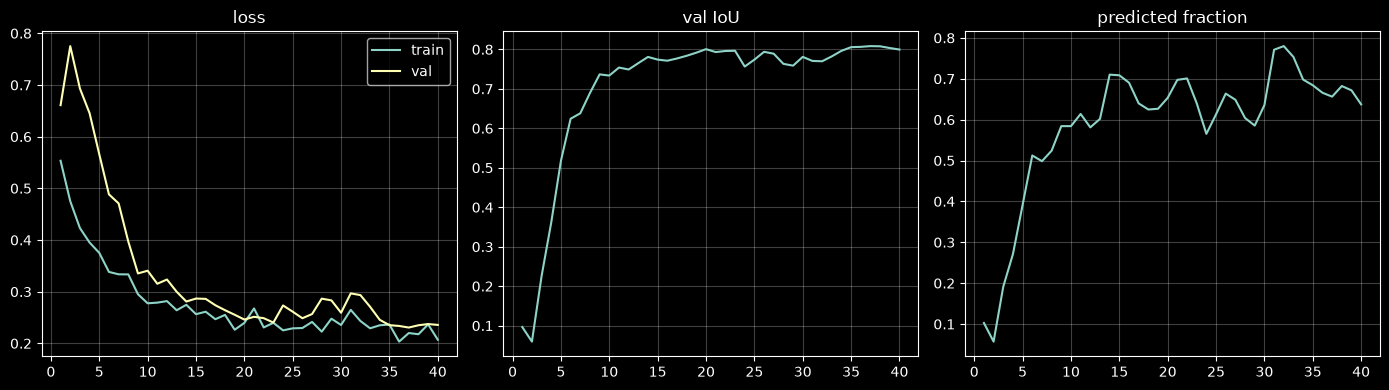

In [8]:
history_df = pd.read_csv(RUN_DIR / 'history.csv')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(history_df.epoch, history_df.train_loss, label='train')
axes[0].plot(history_df.epoch, history_df.val_loss, label='val')
axes[0].set_title('loss')
axes[1].plot(history_df.epoch, history_df.val_iou)
axes[1].set_title('val IoU')
axes[2].plot(history_df.epoch, history_df.val_pred_fraction)
axes[2].set_title('predicted fraction')
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend() if ax is axes[0] else None
plt.tight_layout()
fig.savefig(OUT / 'training_curves.png', dpi=160, bbox_inches='tight')


D:\Nornikel-2026-Shlif-Case\notebooks\spbgu_unet_experiments\outputs\ai_studio_reproduction\previews\ai_studio_val_predictions.png


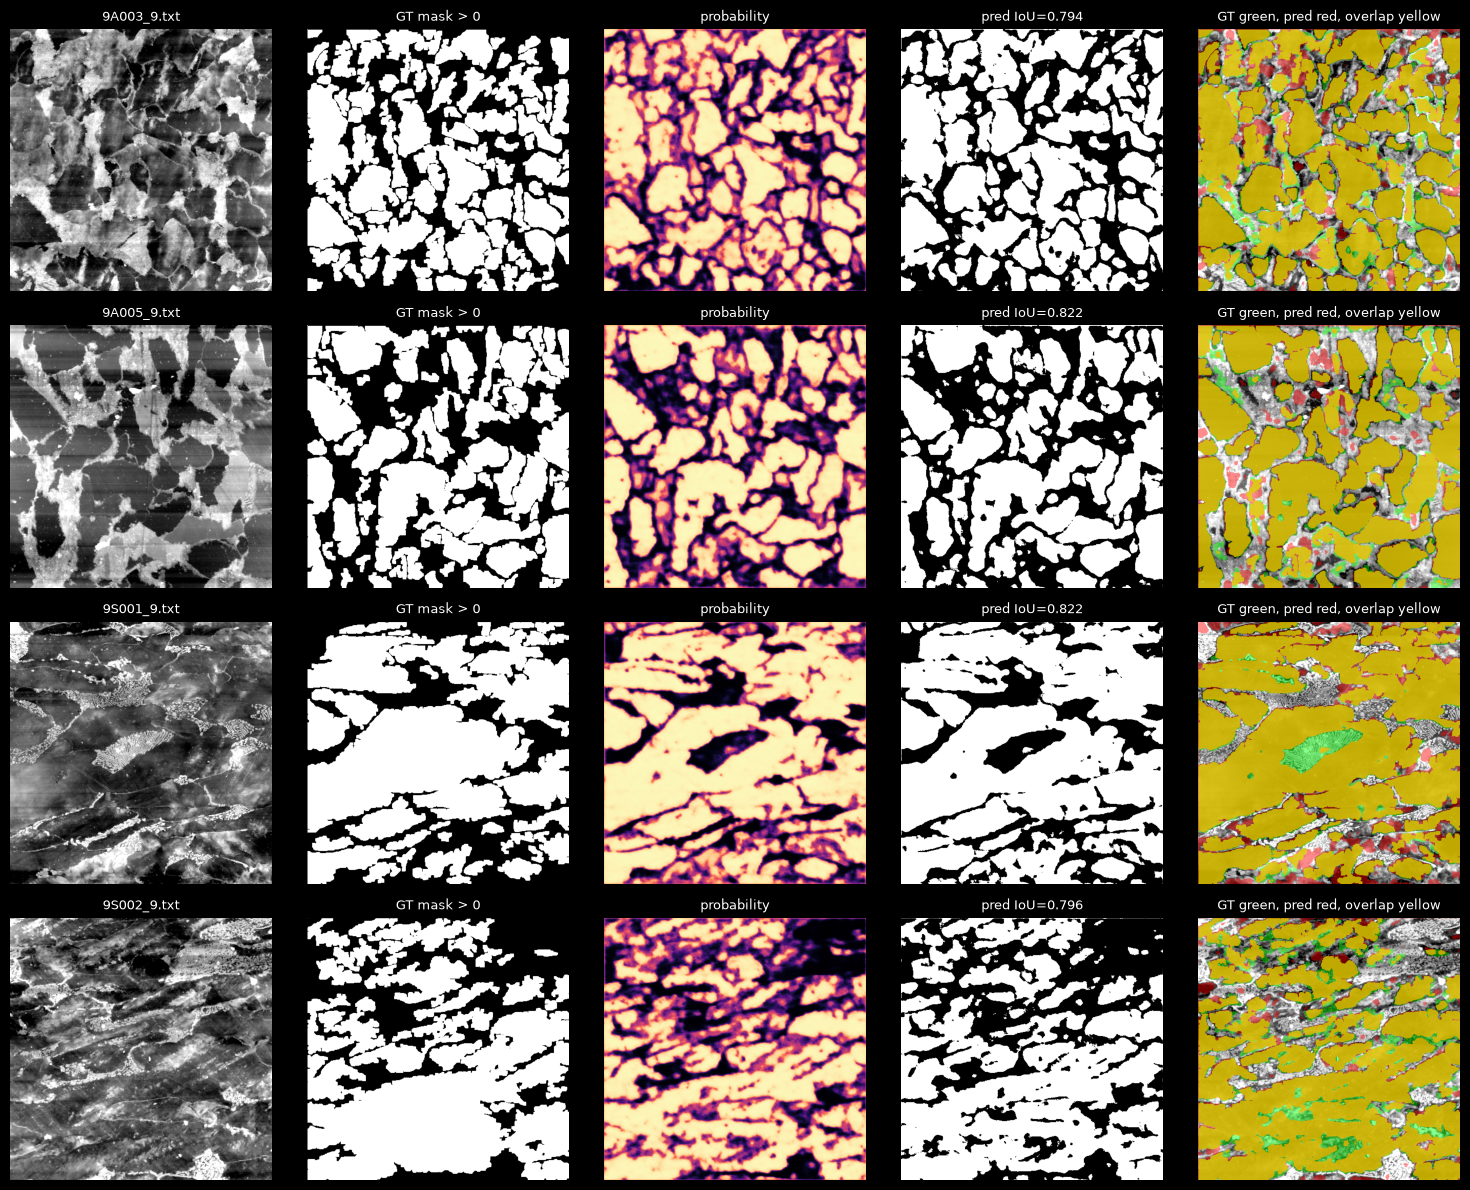

In [10]:
best_state = torch.load(RUN_DIR / 'best_steel_unet_pro_txt_state_dict.pth', map_location=device)
model.load_state_dict(best_state)
model.eval()

preview_rows = []
with torch.no_grad():
    for txt_path, mask_path in zip(val_txt_paths, val_mask_paths):
        image_np = height_to_rgb(txt_path)
        mask_array = np.fromfile(mask_path, dtype=np.uint8)
        mask_decoded = cv2.imdecode(mask_array, cv2.IMREAD_GRAYSCALE)
        mask_np = (mask_decoded > 0)
        normalized = A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))(image=image_np)['image']
        tensor = ToTensorV2()(image=normalized)['image'].unsqueeze(0).to(device)
        logits = model(tensor)
        prob = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()
        pred = prob >= 0.5
        inter = (pred & mask_np).sum()
        union = (pred | mask_np).sum()
        iou = inter / union if union else 1.0
        preview_rows.append((txt_path, image_np, mask_np, prob, pred, iou))

fig, axes = plt.subplots(len(preview_rows), 5, figsize=(15, 3 * len(preview_rows)))
if len(preview_rows) == 1:
    axes = axes[None, :]

for row_idx, (txt_path, image_np, mask_np, prob, pred, iou) in enumerate(preview_rows):
    overlay = image_np.astype(np.float32).copy()
    overlay[mask_np] = 0.55 * overlay[mask_np] + 0.45 * np.array([0, 255, 0], dtype=np.float32)
    overlay[pred] = 0.55 * overlay[pred] + 0.45 * np.array([255, 0, 0], dtype=np.float32)
    both = mask_np & pred
    overlay[both] = 0.45 * overlay[both] + 0.55 * np.array([255, 255, 0], dtype=np.float32)
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    panels = [image_np, mask_np, prob, pred, overlay]
    titles = [Path(txt_path).name, 'GT mask > 0', 'probability', f'pred IoU={iou:.3f}', 'GT green, pred red, overlap yellow']
    for col_idx, (panel, title) in enumerate(zip(panels, titles)):
        ax = axes[row_idx, col_idx]
        if panel.dtype == bool:
            ax.imshow(panel, cmap='gray')
        elif panel.ndim == 2:
            ax.imshow(panel, cmap='magma', vmin=0, vmax=1)
        else:
            ax.imshow(panel)
        ax.set_title(title, fontsize=9)
        ax.axis('off')

plt.tight_layout()
preview_path = PREVIEW_DIR / 'ai_studio_val_predictions.png'
fig.savefig(preview_path, dpi=160, bbox_inches='tight')
print(preview_path)
